# Standard problem 3

## Problem specification

This problem is to calculate a single domain limit of a cubic magnetic particle. This is the size $L$ of equal energy for the so-called flower state (which one may also call a splayed state or a modified single-domain state) on the one hand, and the vortex or curling state on the other hand.

Geometry:

A cube with edge length, $L$, expressed in units of the intrinsic length scale, $l_\text{ex} = \sqrt{A/K_\text{m}}$, where $K_\text{m}$ is a magnetostatic energy density, $K_\text{m} = \frac{1}{2}\mu_{0}M_\text{s}^{2}$.

Material parameters: 

- uniaxial anisotropy $K_\text{u}$ with $K_\text{u} = 0.1 K_\text{m}$, and with the easy axis directed parallel to a principal axis of the cube (0, 0, 1),
- exchange energy constant is $A = \frac{1}{2}\mu_{0}M_\text{s}^{2}l_\text{ex}^{2}$.

More details about the standard problem 3 can be found in Ref. 1.

## Simulation

Firstly, we import all necessary modules and configure pyvista for static rendering.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import time
from scipy import constants

import neuralmag as nm

pv.set_jupyter_backend("static")

SOLVER_LABELS = {
    "llg": "LLG relax",
    "bb": "BB steepest descent",
}

# Switch between the damped-LLG relaxer and the Barzilai-Borwein steepest descent driver.
SELECTED_METHOD = "bb"


2026-04-22 15:46:26 NeuralMag:INFO [NeuralMag] Version 0.9.4


The following two functions are used for initialising the system's magnetisation [1].

In [2]:
# Function for initiaising the flower state.
def m_init_flower(state):
    return nm.VectorFunction(state).fill((0.0, 0.0, 1))


# Function for initialising the vortex state.
def m_init_vortex(state):
    x, y, z = state.coordinates(spaces="nnn", numpy=True)
    m = np.stack([np.ones_like(x) * 1e-9, z, -y], axis=-1)
    norm = np.linalg.norm(m, axis=-1, keepdims=True)
    return nm.VectorFunction(state, tensor=state.tensor(m / norm))

The following function is used for convenience. It takes two required arguments and one optional argument:

- $L$ - the cube edge length in units of $l_\text{ex}$,
- the function for initialising the system's magnetization, and
- the minimisation method, which defaults to `SELECTED_METHOD`.

By default it returns the relaxed system object. If `return_meta=True`, it also returns runtime and iteration metadata so that the notebook can compare the damped-LLG relaxer with the Barzilai-Borwein steepest descent driver.

Please refer to other tutorials for more details on how to create system objects and drive them using specific drivers.

In [3]:
def minimise_system_energy(L, m_init, method=SELECTED_METHOD, return_meta=False):
    N = 10  # discretisation in one dimension
    Ms = 8e5  # saturation magnetization
    A = 13e-12  # exchange constant
    Km = constants.mu_0 * Ms**2 / 2.0  # effective anisotropy
    lex = (A / Km) ** 0.5  # exchange length
    dx = L * lex / N

    mesh = nm.Mesh((N, N, N), (dx, dx, dx), origin=(-L * lex / 2, -L * lex / 2, -L * lex / 2))
    state = nm.State(mesh)

    state.material.Ms = Ms
    state.material.A = A
    state.material.alpha = 0.5
    state.material.Ku = 0.1 * Km
    state.material.Ku_axis = [0, 0, 1]

    state.m = m_init(state)

    nm.ExchangeField().register(state, "exchange")
    nm.UniaxialAnisotropyField().register(state, "aniso")
    nm.DemagField().register(state, "demag")
    nm.TotalField("exchange", "demag", "aniso").register(state)

    t_start = time.perf_counter()
    if method == "llg":
        solver = nm.LLGSolver(state)
        solver.relax()
        meta = {"runtime_s": time.perf_counter() - t_start, "iterations": None}
    elif method == "bb":
        solver = nm.EnergyMinimizer(state, tol=1e3, max_iter=2000)
        solver.minimize()
        meta = {"runtime_s": time.perf_counter() - t_start, "iterations": solver.n_iter}
    else:
        raise ValueError(f"Unknown minimization method: {method}")

    if return_meta:
        return state, meta
    return state


def estimate_crossing(L_array, flower_energies, vortex_energies):
    delta_E = np.subtract(vortex_energies, flower_energies)
    sign_change_indices = np.where(np.diff(np.sign(delta_E)))[0]
    if len(sign_change_indices) == 0:
        return None, delta_E

    zero_crossings = []
    for index in sign_change_indices:
        x1, x2 = L_array[index], L_array[index + 1]
        y1, y2 = delta_E[index], delta_E[index + 1]
        zero_crossing = x1 - y1 * (x2 - x1) / (y2 - y1)
        zero_crossings.append(zero_crossing)

    return abs(zero_crossings[0]), delta_E


def compare_minimizers(L_array, methods=("llg", "bb")):
    comparison = {}
    for method in methods:
        vortex_energies, flower_energies = [], []
        runtimes = []
        iterations = []

        for L in L_array:
            vortex, vortex_meta = minimise_system_energy(L, m_init_vortex, method=method, return_meta=True)
            flower, flower_meta = minimise_system_energy(L, m_init_flower, method=method, return_meta=True)

            vortex_energies.append(float(np.asarray(nm.config.backend.to_numpy(vortex.E))))
            flower_energies.append(float(np.asarray(nm.config.backend.to_numpy(flower.E))))
            runtimes.append(vortex_meta["runtime_s"] + flower_meta["runtime_s"])

            if vortex_meta["iterations"] is not None:
                iterations.append(vortex_meta["iterations"] + flower_meta["iterations"])

        crossing, delta_E = estimate_crossing(L_array, flower_energies, vortex_energies)
        comparison[method] = {
            "vortex_energies": vortex_energies,
            "flower_energies": flower_energies,
            "delta_E": delta_E,
            "crossing": crossing,
            "total_runtime_s": float(np.sum(runtimes)),
            "avg_runtime_s": float(np.mean(runtimes)),
            "avg_iterations": float(np.mean(iterations)) if iterations else None,
        }

    return comparison


def compare_state_images(L, m_init, state_name, methods=("llg", "bb")):
    plotter = pv.Plotter(shape=(1, len(methods)))
    summaries = []

    for column, method in enumerate(methods):
        state, meta = minimise_system_energy(L, m_init, method=method, return_meta=True)
        filename = f"standard-problem-3/{state_name.lower()}-{method}-comparison.vti"
        state.write_vti(["m"], filename)

        mesh = pv.read(filename)
        glyphs = mesh.glyph(orient="m", scale="m", factor=1e-8)

        plotter.subplot(0, column)
        plotter.add_text(SOLVER_LABELS[method], font_size=12)
        plotter.add_mesh(glyphs, color="white", lighting=True, smooth_shading=True)
        plotter.view_isometric()

        summaries.append({
            "method": method,
            "energy": float(np.asarray(nm.config.backend.to_numpy(state.E))),
            "runtime_s": meta["runtime_s"],
            "iterations": meta["iterations"],
        })

    plotter.link_views()
    plotter.show()
    return summaries


def print_state_image_summary(state_name, summaries):
    print(f"{state_name} state comparison")
    for values in summaries:
        line = (
            f"- {SOLVER_LABELS[values['method']]}: E = {values['energy']:.6e} J, "
            f"runtime = {values['runtime_s']:.2f}s"
        )
        if values["iterations"] is not None:
            line += f", BB iterations = {values['iterations']}"
        print(line)


def plot_method_comparison(L_array, comparison):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for method, values in comparison.items():
        label = SOLVER_LABELS[method]
        axes[0].plot(L_array, values["flower_energies"], "o--", label=f"flower ({label})")
        axes[0].plot(L_array, values["vortex_energies"], "o-", label=f"vortex ({label})")

        crossing_label = label
        if values["crossing"] is not None:
            crossing_label += f", L*={values['crossing']:.3f}"
        axes[1].plot(L_array, values["delta_E"], "o-", label=crossing_label)

    axes[0].set_xlabel("L (lex)")
    axes[0].set_ylabel("E (J)")
    axes[0].set_title("Method comparison by state")
    axes[0].grid()
    axes[0].legend()

    axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle=":")
    axes[1].set_xlabel("L (lex)")
    axes[1].set_ylabel(r"$E_\mathrm{vortex} - E_\mathrm{flower}$ (J)")
    axes[1].set_title("Crossing comparison")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def print_method_summary(comparison):
    print("Method comparison for standard problem 3")
    for method, values in comparison.items():
        line = (
            f"- {SOLVER_LABELS[method]}: crossing ~= {values['crossing']:.3f}, "
            f"total runtime = {values['total_runtime_s']:.2f}s, "
            f"average runtime per L = {values['avg_runtime_s']:.2f}s"
        )
        if values["avg_iterations"] is not None:
            line += f", average BB iterations per L = {values['avg_iterations']:.1f}"
        print(line)

### Relaxed magnetization states

Each image pair below compares the damped-LLG relaxer and the Barzilai-Borwein steepest descent minimizer for the same initial state at $L=8$.

**Vortex** state:

2026-04-22 15:46:26.713 (   0.653s) [    F640F08448E0]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
2026-04-22 15:46:26 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.54864e-09 x 4.54864e-09 x 4.54864e-09)
2026-04-22 15:46:27 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-22 15:46:27 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 15:46:27 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2026-04-22 15:46:36 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 15:46:36 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 15:46:36 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 15:46:36 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-0

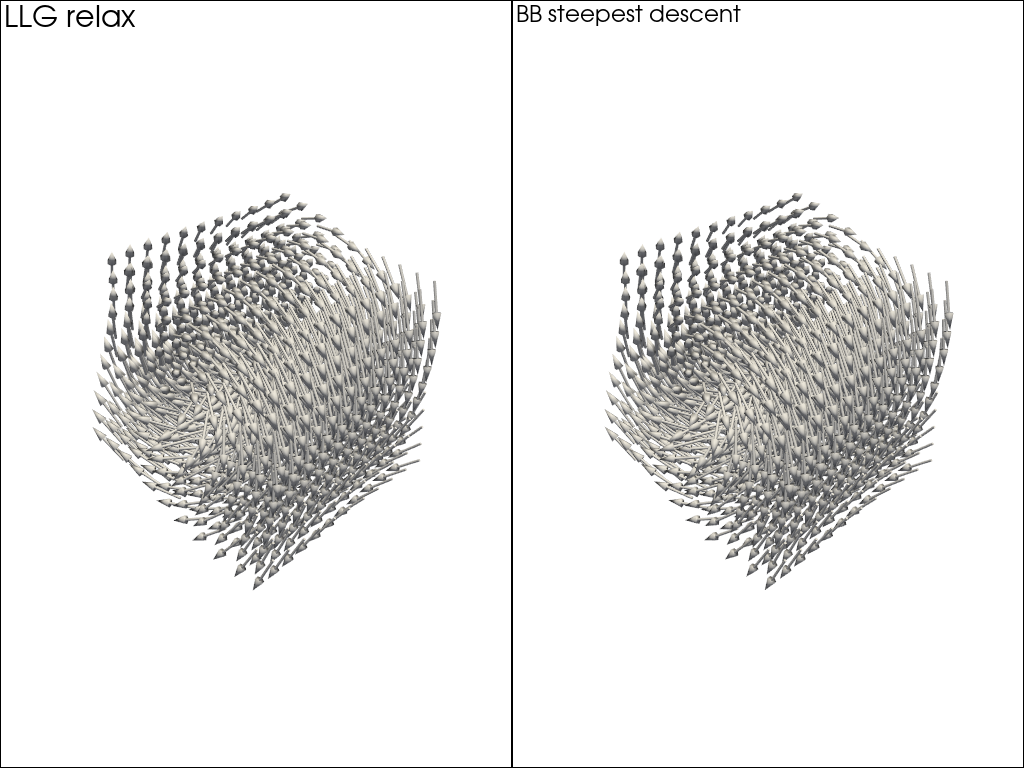

Vortex state comparison
- LLG relax: E = 8.320369e-18 J, runtime = 14.64s
- BB steepest descent: E = 8.320460e-18 J, runtime = 11.78s, BB iterations = 31


In [4]:
vortex_images = compare_state_images(8, m_init_vortex, "vortex")
print_state_image_summary("Vortex", vortex_images)

**Flower** state:

2026-04-22 15:47:08 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.54864e-09 x 4.54864e-09 x 4.54864e-09)
2026-04-22 15:47:08 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 15:47:08 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 15:47:08 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 15:47:08 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 15:47:08 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 15:47:08 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 15:47:10 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 15:47:10 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-22 15:47:

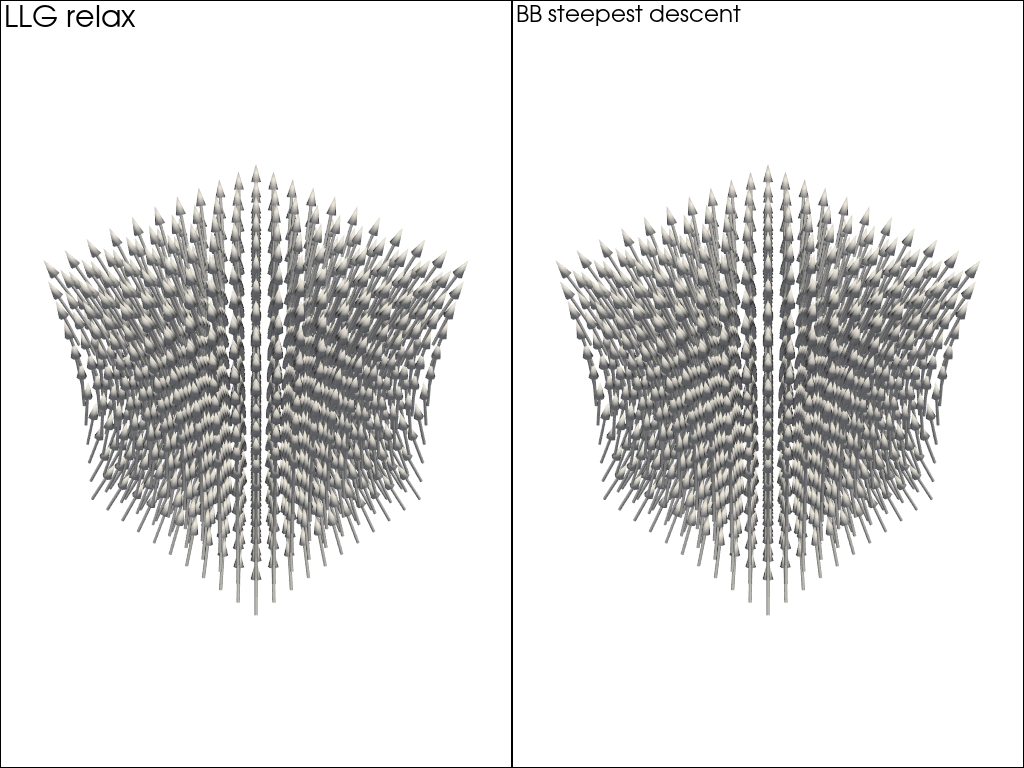

Flower state comparison
- LLG relax: E = 7.784920e-18 J, runtime = 13.36s
- BB steepest descent: E = 7.784938e-18 J, runtime = 11.48s, BB iterations = 12


In [5]:
flower_images = compare_state_images(8, m_init_flower, "flower")
print_state_image_summary("Flower", flower_images)

### Energy crossing

We can plot the energies of both vortex and flower states as a function of cube edge length $L$. The first plot below shows the selected method, while the second plot compares the damped-LLG relaxer and the Barzilai-Borwein steepest descent minimizer directly. The printed summary reports the crossing estimate, wall time, and BB iteration counts.

2026-04-22 15:47:37 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.71922e-09 x 4.71922e-09 x 4.71922e-09)
2026-04-22 15:47:37 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 15:47:37 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 15:47:37 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 15:47:37 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 15:47:37 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 15:47:37 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 15:47:39 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 15:47:39 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-22 15:47:

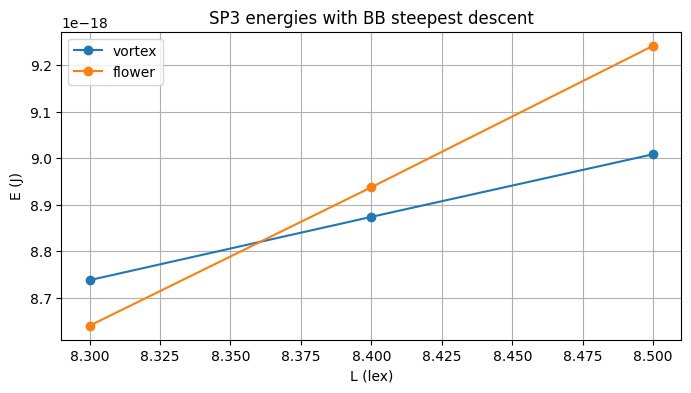

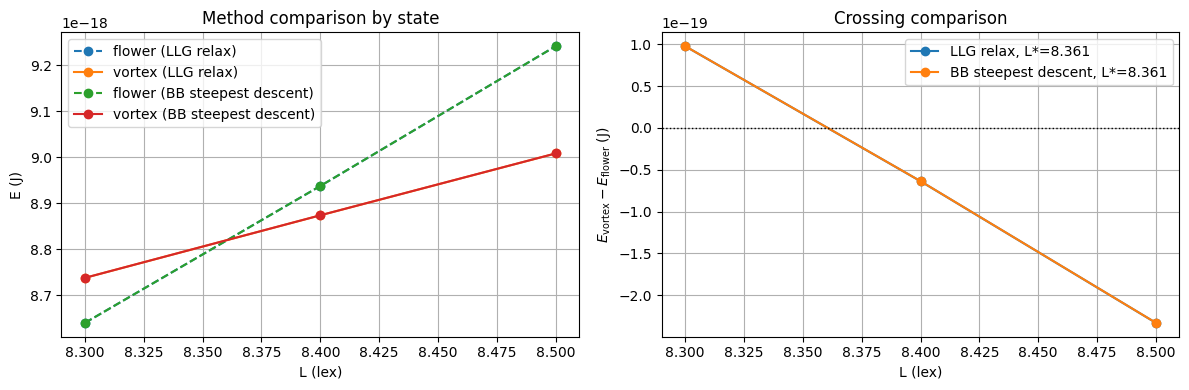

Method comparison for standard problem 3
- LLG relax: crossing ~= 8.361, total runtime = 81.18s, average runtime per L = 27.06s
- BB steepest descent: crossing ~= 8.361, total runtime = 70.26s, average runtime per L = 23.42s, average BB iterations per L = 40.7


In [6]:
L_array = [8.3, 8.4, 8.5]
comparison = compare_minimizers(L_array)

selected = comparison[SELECTED_METHOD]
plt.figure(figsize=(8, 4))
plt.plot(L_array, selected["vortex_energies"], "o-", label="vortex")
plt.plot(L_array, selected["flower_energies"], "o-", label="flower")
plt.xlabel("L (lex)")
plt.ylabel("E (J)")
plt.title(f"SP3 energies with {SOLVER_LABELS[SELECTED_METHOD]}")
plt.grid()
plt.legend()
plt.show()

plot_method_comparison(L_array, comparison)
print_method_summary(comparison)

Both methods should place the energy crossing in the same $8.3l_\text{ex}$ to $8.5l_\text{ex}$ interval. The comparison plot and printed summary let you check whether the BB minimizer reaches the same static energies with fewer iterations or lower wall time than the damped-LLG relaxer for this setup.

### Reduced energy landscape

The full micromagnetic energy landscape lives in a very high-dimensional space, so it cannot be visualized directly. What we can plot here is a **2D reduced slice** through magnetization space around a chosen minimum.

This is **not** a spatial $x$-$y$ map of the cube. Each plotted point corresponds to a sampled magnetization state of the form $m(c_1, c_2) = \mathrm{normalize}(m_\mathrm{ref} + c_1 e_1 + c_2 e_2)$, where $m_\mathrm{ref}$ is the relaxed reference state. The first axis points roughly toward the competing minimum, and the second axis is an orthogonal perturbation direction.

The contour or surface height shows the raw energy on that reduced slice, and the white BB path shows how the minimizer moves through the same 2D chart starting from the chosen initial state. On JAX, the energy-grid evaluation in this helper is already batched with `vmap`. If you want to start the path from a random magnetization instead of the default target initial guess, call `plot_energy_landscape(..., initial="random", random_seed=7)` or choose any other integer seed.

In [7]:
def build_sp3_state(L, m_init):
    N = 10  # discretisation in one dimension
    Ms = 8e5  # saturation magnetization
    A = 13e-12  # exchange constant
    Km = constants.mu_0 * Ms**2 / 2.0  # effective anisotropy
    lex = (A / Km) ** 0.5  # exchange length
    dx = L * lex / N

    mesh = nm.Mesh((N, N, N), (dx, dx, dx), origin=(-L * lex / 2, -L * lex / 2, -L * lex / 2))
    state = nm.State(mesh)

    state.material.Ms = Ms
    state.material.A = A
    state.material.alpha = 0.5
    state.material.Ku = 0.1 * Km
    state.material.Ku_axis = [0, 0, 1]

    state.m = m_init(state)

    nm.ExchangeField().register(state, "exchange")
    nm.UniaxialAnisotropyField().register(state, "aniso")
    nm.DemagField().register(state, "demag")
    nm.TotalField("exchange", "demag", "aniso").register(state)
    return state


def _scalar_as_float(value):
    return float(np.asarray(nm.config.backend.to_numpy(value)).reshape(()))


def _m_as_numpy(state):
    return np.asarray(nm.config.backend.to_numpy(state.m.tensor), dtype=float)


def _global_dot(lhs, rhs):
    return float(np.sum(lhs * rhs))


def _global_norm(value):
    return np.sqrt(max(_global_dot(value, value), 1e-30))


def _normalize_field(value):
    norms = np.linalg.norm(value, axis=-1, keepdims=True)
    return value / np.maximum(norms, 1e-14)


def _project_tangent(direction, reference):
    return direction - np.sum(direction * reference, axis=-1, keepdims=True) * reference


def _orthonormal_tangent_basis(reference, direction_1, direction_2):
    basis_1 = _project_tangent(direction_1, reference)
    basis_1 /= _global_norm(basis_1)

    basis_2 = _project_tangent(direction_2, reference)
    basis_2 -= _global_dot(basis_2, basis_1) * basis_1
    basis_2_norm = _global_norm(basis_2)
    if basis_2_norm < 1e-10:
        raise ValueError("The chosen energy-slice directions are nearly collinear.")
    basis_2 /= basis_2_norm
    return basis_1, basis_2


def _project_onto_basis(m, reference, basis_1, basis_2):
    delta = _project_tangent(m - reference, reference)
    return _global_dot(delta, basis_1), _global_dot(delta, basis_2)


def _make_random_m_init(seed=None):
    def m_init_random(state):
        x, _, _ = state.coordinates(spaces="nnn", numpy=True)
        rng = np.random.default_rng(seed)
        m = rng.normal(size=x.shape + (3,))
        m = _normalize_field(m)
        return nm.VectorFunction(state, tensor=state.tensor(m))

    return m_init_random


def _resolve_initial_m_init(initial, target_init, other_init, random_seed):
    init_map = {"target": target_init, "other": other_init}
    if callable(initial):
        return initial, "custom initial state"
    if initial == "random":
        label = "random initial state" if random_seed is None else f"random initial state (seed={random_seed})"
        return _make_random_m_init(random_seed), label
    if initial in init_map:
        label = "target initial state" if initial == "target" else "competing-state initial guess"
        return init_map[initial], label
    raise ValueError("initial must be 'target', 'other', 'random', or a callable m_init(state).")


_RELAXED_SP3_MINIMUM_CACHE = {}


def _get_relaxed_sp3_minimum(L, target, method, init_map):
    key = (float(np.asarray(L).reshape(())), target, method)
    cached = _RELAXED_SP3_MINIMUM_CACHE.get(key)
    if cached is None:
        state, meta = minimise_system_energy(L, init_map[target], method=method, return_meta=True)
        cached = {
            "m": _m_as_numpy(state),
            "energy": _scalar_as_float(state.E),
            "meta": meta,
        }
        _RELAXED_SP3_MINIMUM_CACHE[key] = cached
    return cached


def _evaluate_energy_slice(L, template_init, reference, basis_1, basis_2, a_values, b_values, batch_size=128):
    state = build_sp3_state(L, template_init)
    a_grid, b_grid = np.meshgrid(a_values, b_values)
    flat_a = a_grid.reshape(-1)
    flat_b = b_grid.reshape(-1)

    m_trials = reference[None, ...] + flat_a[:, None, None, None, None] * basis_1[None, ...]
    m_trials += flat_b[:, None, None, None, None] * basis_2[None, ...]
    m_trials = _normalize_field(m_trials)

    if getattr(nm.config.backend, "name", None) == "jax":
        import jax

        energy_fn = jax.jit(state.resolve(lambda m, E: E, ["m"]))
        batched_energy_fn = jax.jit(jax.vmap(energy_fn))
        flat_energies = []
        for start in range(0, m_trials.shape[0], batch_size):
            stop = start + batch_size
            flat_energies.append(np.asarray(batched_energy_fn(state.tensor(m_trials[start:stop]))))
        return np.concatenate(flat_energies).reshape(len(b_values), len(a_values))

    energies = np.empty((len(b_values), len(a_values)))
    for row, b_value in enumerate(b_values):
        for col, a_value in enumerate(a_values):
            m_trial = _normalize_field(reference + a_value * basis_1 + b_value * basis_2)
            state.m.tensor = state.tensor(m_trial)
            energies[row, col] = _scalar_as_float(state.E)
    return energies


def _record_bb_path(
    L,
    state_or_init,
    reference,
    basis_1,
    basis_2,
    max_iter=60,
    tol=1e3,
    record_energies=True,
):
    state = state_or_init if hasattr(state_or_init, "m") else build_sp3_state(L, state_or_init)
    minimizer = nm.EnergyMinimizer(state, tol=tol, max_iter=max_iter)

    path = [_project_onto_basis(_m_as_numpy(state), reference, basis_1, basis_2)]
    energies = [_scalar_as_float(state.E)] if record_energies else None

    max_g = np.inf
    while minimizer.n_iter < max_iter and max_g > tol:
        max_g = _scalar_as_float(minimizer.step())
        path.append(_project_onto_basis(_m_as_numpy(state), reference, basis_1, basis_2))
        if record_energies:
            energies.append(_scalar_as_float(state.E))

    if record_energies:
        return np.asarray(path), np.asarray(energies)
    return np.asarray(path), None


def plot_energy_landscape(
    L=8.4,
    target="flower",
    method="bb",
    grid_size=21,
    max_iter=60,
    tol=1e3,
    surface=False,
    batch_size=128,
    extent=1.25,
    initial="target",
    random_seed=None,
    record_path_energies=None,
):
    init_map = {"flower": m_init_flower, "vortex": m_init_vortex}
    if target not in init_map:
        raise ValueError("target must be 'flower' or 'vortex'.")

    other_target = "vortex" if target == "flower" else "flower"
    target_init = init_map[target]
    other_init = init_map[other_target]
    initial_init, initial_label = _resolve_initial_m_init(initial, target_init, other_init, random_seed)

    if record_path_energies is None:
        record_path_energies = surface
    if surface and not record_path_energies:
        raise ValueError("surface=True requires record_path_energies=True.")

    reference_minimum = _get_relaxed_sp3_minimum(L, target, method, init_map)
    other_minimum = _get_relaxed_sp3_minimum(L, other_target, method, init_map)
    initial_state = build_sp3_state(L, initial_init)

    reference_m = reference_minimum["m"]
    other_m = other_minimum["m"]
    initial_m = _m_as_numpy(initial_state)

    basis_1, basis_2 = _orthonormal_tangent_basis(
        reference_m,
        other_m - reference_m,
        initial_m - reference_m,
    )

    other_a, other_b = _project_onto_basis(other_m, reference_m, basis_1, basis_2)
    initial_a, initial_b = _project_onto_basis(initial_m, reference_m, basis_1, basis_2)

    a_extent = extent * max(abs(other_a), abs(initial_a), 0.05)
    b_extent = extent * max(abs(other_b), abs(initial_b), 0.05)
    a_values = np.linspace(-a_extent, a_extent, grid_size)
    b_values = np.linspace(-b_extent, b_extent, grid_size)
    a_grid, b_grid = np.meshgrid(a_values, b_values)

    energies = _evaluate_energy_slice(
        L,
        target_init,
        reference_m,
        basis_1,
        basis_2,
        a_values,
        b_values,
        batch_size=batch_size,
    )
    path, path_energies = _record_bb_path(
        L,
        initial_state,
        reference_m,
        basis_1,
        basis_2,
        max_iter=max_iter,
        tol=tol,
        record_energies=record_path_energies,
    )

    reference_energy = reference_minimum["energy"]
    delta_energies = energies - reference_energy
    delta_path_energies = None if path_energies is None else path_energies - reference_energy

    if surface:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection="3d")
        surface_plot = ax.plot_surface(a_grid, b_grid, delta_energies, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
        ax.plot(path[:, 0], path[:, 1], delta_path_energies, color="white", marker="o", linewidth=1.5, markersize=3, label="BB path")
        ax.scatter([0.0], [0.0], [0.0], color="red", s=50, label=f"{target} minimum")
        ax.scatter([other_a], [other_b], [delta_energies[np.abs(b_values - other_b).argmin(), np.abs(a_values - other_a).argmin()]], color="cyan", s=40, label=f"{other_target} minimum")
        ax.scatter([initial_a], [initial_b], [delta_energies[np.abs(b_values - initial_b).argmin(), np.abs(a_values - initial_a).argmin()]], color="orange", s=40, label=initial_label)
        ax.set_xlabel(r"$c_1$ coefficient toward the competing minimum")
        ax.set_ylabel(r"$c_2$ coefficient for the orthogonal perturbation")
        ax.set_zlabel(r"$E - E_\mathrm{min}$ (J)")
        ax.set_title(
            "SP3 reduced energy slice\n"
            f"Each (c1, c2) is a sampled magnetization on a 2D slice around the {target} minimum"
        )
        fig.colorbar(surface_plot, ax=ax, pad=0.1, shrink=0.7, label=r"$E - E_\mathrm{min}$ (J)")
        ax.legend()
        plt.show()
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        filled = ax.contourf(a_grid, b_grid, delta_energies, levels=25, cmap="viridis")
        ax.contour(a_grid, b_grid, delta_energies, levels=25, colors="black", linewidths=0.5, alpha=0.35)
        ax.plot(path[:, 0], path[:, 1], color="white", marker="o", linewidth=1.5, markersize=3, label="BB path")
        ax.scatter([0.0], [0.0], color="red", s=60, label=f"{target} minimum")
        ax.scatter([other_a], [other_b], color="cyan", s=50, label=f"{other_target} minimum")
        ax.scatter([initial_a], [initial_b], color="orange", s=50, label=initial_label)
        ax.set_xlabel(r"$c_1$ coefficient toward the competing minimum")
        ax.set_ylabel(r"$c_2$ coefficient for the orthogonal perturbation")
        ax.set_title(
            "SP3 reduced energy slice\n"
            f"Each (c1, c2) is a sampled magnetization on a 2D slice around the {target} minimum"
        )
        fig.colorbar(filled, ax=ax, label=r"$E - E_\mathrm{min}$ (J)")
        ax.legend()
        plt.show()

    return {
        "a_grid": a_grid,
        "b_grid": b_grid,
        "delta_energies": delta_energies,
        "path": path,
        "delta_path_energies": delta_path_energies,
        "reference_energy": reference_energy,
        "target": target,
        "method": method,
        "initial": initial,
        "initial_label": initial_label,
        "random_seed": random_seed,
        "record_path_energies": record_path_energies,
    }


plot_energy_landscape_slice = plot_energy_landscape

In [8]:
def _field_as_numpy(value):
    tensor = value.tensor if hasattr(value, "tensor") else value
    return np.asarray(nm.config.backend.to_numpy(tensor), dtype=float)


def _descent_direction_numpy(m, h):
    return np.cross(m, np.cross(m, h))


def _fallback_tangent_direction(reference):
    candidate = np.zeros_like(reference)
    candidate[..., 0] = -reference[..., 1]
    candidate[..., 1] = reference[..., 0]
    if _global_norm(_project_tangent(candidate, reference)) < 1e-10:
        candidate = np.zeros_like(reference)
        candidate[..., 1] = -reference[..., 2]
        candidate[..., 2] = reference[..., 1]
    return candidate


def _local_start_basis(reference, descent_direction, competing_direction):
    primary = descent_direction
    secondary = competing_direction

    if _global_norm(_project_tangent(primary, reference)) < 1e-10:
        primary = _fallback_tangent_direction(reference)
    if _global_norm(_project_tangent(secondary, reference)) < 1e-10:
        secondary = _fallback_tangent_direction(reference)

    try:
        return _orthonormal_tangent_basis(reference, primary, secondary)
    except ValueError:
        return _orthonormal_tangent_basis(reference, primary, _fallback_tangent_direction(reference))


def _relax_many_in_chunks(L, m_init, m_batch, max_iter=60, tol=1e3, chunk_size=32):
    state = build_sp3_state(L, m_init)
    solver = nm.EnergyMinimizer(state, tol=tol, max_iter=max_iter)
    if not hasattr(solver, "minimize_many"):
        raise ValueError(
            "plot_basin_map currently requires the JAX backend because it uses EnergyMinimizer.minimize_many()."
        )

    leading_shape = m_batch.shape[:2]
    flat_batch = m_batch.reshape((-1,) + m_batch.shape[2:])
    chunk_size = flat_batch.shape[0] if chunk_size is None else chunk_size

    final_chunks = []
    n_iter_chunks = []
    converged_chunks = []
    max_g_chunks = []

    for start in range(0, flat_batch.shape[0], chunk_size):
        stop = start + chunk_size
        m_final, info = solver.minimize_many(flat_batch[start:stop], return_info=True)
        final_chunks.append(_field_as_numpy(m_final))
        n_iter_chunks.append(_field_as_numpy(info["n_iter"]))
        converged_chunks.append(np.asarray(nm.config.backend.to_numpy(info["converged"]), dtype=bool))
        max_g_chunks.append(_field_as_numpy(info["max_g"]))

    state_shape = flat_batch.shape[1:]
    final_states = np.concatenate(final_chunks, axis=0).reshape(leading_shape + state_shape)
    info = {
        "n_iter": np.concatenate(n_iter_chunks, axis=0).reshape(leading_shape),
        "converged": np.concatenate(converged_chunks, axis=0).reshape(leading_shape),
        "max_g": np.concatenate(max_g_chunks, axis=0).reshape(leading_shape),
    }
    return final_states, info


def _batch_l2_distance(states, reference):
    flat_states = states.reshape((states.shape[0], -1))
    flat_reference = reference.reshape(-1)
    return np.linalg.norm(flat_states - flat_reference[None, :], axis=-1)


def _classify_relaxed_states(final_states, flower_m, vortex_m, unknown_tol=0.2):
    flat_states = final_states.reshape((-1,) + final_states.shape[2:])
    flower_dist = _batch_l2_distance(flat_states, flower_m)
    vortex_dist = _batch_l2_distance(flat_states, vortex_m)
    reference_dist = _global_norm(flower_m - vortex_m)

    labels = np.where(flower_dist <= vortex_dist, 0, 1)
    min_dist = np.minimum(flower_dist, vortex_dist)
    labels[min_dist > unknown_tol * reference_dist] = -1

    grid_shape = final_states.shape[:2]
    return labels.reshape(grid_shape), {
        "flower_dist": flower_dist.reshape(grid_shape),
        "vortex_dist": vortex_dist.reshape(grid_shape),
    }


def plot_basin_map(
    L=8.4,
    start="flower",
    grid_size=11,
    max_iter=60,
    tol=1e3,
    batch_size=128,
    chunk_size=32,
    unknown_tol=0.2,
    show_energy_contours=True,
    extent_scale=1.1,
    method="bb",
):
    if method != "bb":
        raise ValueError("plot_basin_map currently supports only method='bb'.")
    if getattr(nm.config.backend, "name", None) != "jax":
        raise ValueError("plot_basin_map currently requires the JAX backend.")

    init_map = {"flower": m_init_flower, "vortex": m_init_vortex}
    if start not in init_map:
        raise ValueError("start must be 'flower' or 'vortex'.")

    start_init = init_map[start]
    start_state = build_sp3_state(L, start_init)
    flower_state, _ = minimise_system_energy(L, m_init_flower, method=method, return_meta=True)
    vortex_state, _ = minimise_system_energy(L, m_init_vortex, method=method, return_meta=True)

    start_m = _m_as_numpy(start_state)
    start_h = _field_as_numpy(start_state.h)
    flower_m = _m_as_numpy(flower_state)
    vortex_m = _m_as_numpy(vortex_state)
    competing_m = vortex_m if start == "flower" else flower_m

    basis_1, basis_2 = _local_start_basis(
        start_m,
        _descent_direction_numpy(start_m, start_h),
        competing_m - start_m,
    )

    flower_a, flower_b = _project_onto_basis(flower_m, start_m, basis_1, basis_2)
    vortex_a, vortex_b = _project_onto_basis(vortex_m, start_m, basis_1, basis_2)

    a_extent = extent_scale * max(abs(flower_a), abs(vortex_a), 0.05)
    b_extent = extent_scale * max(abs(flower_b), abs(vortex_b), 0.05)
    a_values = np.linspace(-a_extent, a_extent, grid_size)
    b_values = np.linspace(-b_extent, b_extent, grid_size)
    a_grid, b_grid = np.meshgrid(a_values, b_values)

    m_trials = start_m[None, None, ...] + a_grid[..., None, None, None, None] * basis_1[None, None, ...]
    m_trials += b_grid[..., None, None, None, None] * basis_2[None, None, ...]
    m_trials = _normalize_field(m_trials)

    final_states, relaxation_info = _relax_many_in_chunks(
        L,
        start_init,
        m_trials,
        max_iter=max_iter,
        tol=tol,
        chunk_size=chunk_size,
    )
    labels, label_info = _classify_relaxed_states(final_states, flower_m, vortex_m, unknown_tol=unknown_tol)
    path, _ = _record_bb_path(L, start_init, start_m, basis_1, basis_2, max_iter=max_iter, tol=tol)

    delta_energies = None
    if show_energy_contours:
        energies = _evaluate_energy_slice(
            L,
            start_init,
            start_m,
            basis_1,
            basis_2,
            a_values,
            b_values,
            batch_size=batch_size,
        )
        delta_energies = energies - _scalar_as_float(start_state.E)

    from matplotlib import colors as mcolors
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    cmap = mcolors.ListedColormap(["#8f8f8f", "#d5a437", "#2b6f9f"])
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contourf(a_grid, b_grid, labels, levels=[-1.5, -0.5, 0.5, 1.5], cmap=cmap, alpha=0.85)
    if delta_energies is not None:
        ax.contour(a_grid, b_grid, delta_energies, levels=20, colors="black", linewidths=0.5, alpha=0.35)

    ax.plot(path[:, 0], path[:, 1], color="white", marker="o", linewidth=1.5, markersize=3)
    ax.scatter([0.0], [0.0], color="black", s=70, zorder=5)
    ax.scatter([flower_a], [flower_b], color="#d5a437", edgecolors="black", linewidths=0.5, s=70, zorder=5)
    ax.scatter([vortex_a], [vortex_b], color="#2b6f9f", edgecolors="black", linewidths=0.5, s=70, zorder=5)

    ax.set_xlabel(r"$c_1$ coefficient for the initial BB-direction perturbation")
    ax.set_ylabel(r"$c_2$ coefficient for the competing-state perturbation")
    ax.set_title(
        "SP3 basin-of-attraction map\n"
        f"Each (c1, c2) is a different perturbed initial magnetization around the {start} starting state"
    )
    ax.legend(
        handles=[
            Patch(facecolor="#d5a437", label="flower basin"),
            Patch(facecolor="#2b6f9f", label="vortex basin"),
            Patch(facecolor="#8f8f8f", label="unclassified"),
            Line2D([0], [0], color="white", marker="o", linewidth=1.5, markersize=4, label="BB path"),
            Line2D([0], [0], color="black", marker="o", linestyle="", markersize=6, label=f"{start} initial state"),
        ]
    )
    ax.grid(alpha=0.2)
    plt.show()

    counts = {
        "flower": int(np.sum(labels == 0)),
        "vortex": int(np.sum(labels == 1)),
        "unknown": int(np.sum(labels == -1)),
    }

    return {
        "a_grid": a_grid,
        "b_grid": b_grid,
        "labels": labels,
        "counts": counts,
        "n_iter": relaxation_info["n_iter"],
        "converged": relaxation_info["converged"],
        "max_g": relaxation_info["max_g"],
        "delta_energies": delta_energies,
        "flower_distance": label_info["flower_dist"],
        "vortex_distance": label_info["vortex_dist"],
        "path": path,
        "start": start,
        "method": method,
    }

2026-04-22 16:00:37 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.77607e-09 x 4.77607e-09 x 4.77607e-09)
2026-04-22 16:00:37 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 16:00:37 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 16:00:37 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 16:00:37 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 16:00:37 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 16:00:37 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 16:00:39 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 16:00:39 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.77607e-09 x 4.77607e-0

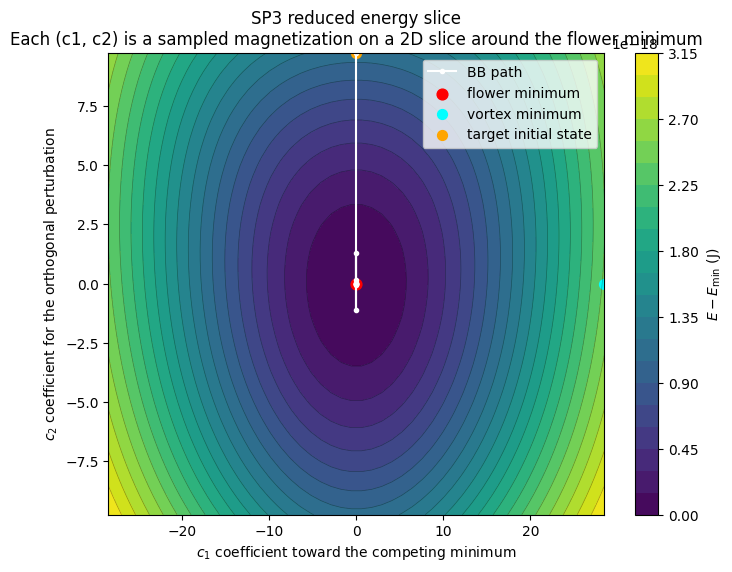

In [12]:
landscape_flower_random_start = plot_energy_landscape(
    L=8.4,
    target="flower",
    method="bb",
    grid_size=50,
    max_iter=100,
    surface=False,
    extent=1,
    random_seed=1,
)

# Optional 3D view of the same reduced slice.
# landscape_flower_surface = plot_energy_landscape(
#     L=8.4,
#     target="flower",
#     method="bb",
#     grid_size=50,
#     max_iter=40,
#     surface=True,
#     initial="random",
#     random_seed=7,
# )

### Local basin map

This is **not** a spatial $x$-$y$ map of the cube. Each plotted point corresponds to a different initial magnetization generated from the chosen starting state via $m(c_1, c_2) = \mathrm{normalize}(m_\mathrm{start} + c_1 e_1 + c_2 e_2)$. The colour shows which relaxed minimum that initial condition reaches after the vmapped BB solve.

The black dot marks the unperturbed starting state, the white curve is the BB trajectory from that exact state, and the contour lines show the raw energy in the same reduced 2D slice.

At the moment this helper is JAX-only because it relies on `EnergyMinimizer.minimize_many(...)`.

2026-04-22 14:44:49 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.77607e-09 x 4.77607e-09 x 4.77607e-09)
2026-04-22 14:44:49 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 14:44:49 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 14:44:49 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 14:44:49 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 14:44:49 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 14:44:49 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 14:44:51 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 14:44:51 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.77607e-09 x 4.77607e-0

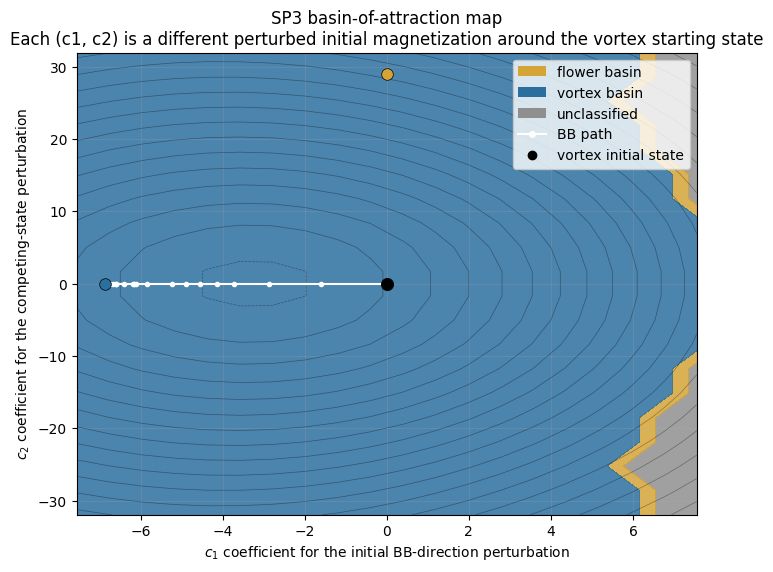

Vmapped basin counts: flower=0, vortex=374, unknown=26
Average BB steps across converged samples: 33.1


In [ ]:
basin_map_vortex = plot_basin_map(
    L=8.4,
    start="vortex",
    grid_size=20,
    max_iter=40,
    chunk_size=100,
    show_energy_contours=True,
)

converged_steps = basin_map_vortex["n_iter"][basin_map_vortex["converged"]]
print(
    "Vmapped basin counts: " + ", ".join(
        f"{name}={value}" for name, value in basin_map_vortex["counts"].items()
    )
)
if converged_steps.size:
    print(f"Average BB steps across converged samples: {converged_steps.mean():.1f}")

## References

[1] µMAG Site Directory http://www.ctcms.nist.gov/~rdm/mumag.org.

This tutorial was adapted from [Ubermag](https://ubermag.github.io/).